In [92]:
import pandas as pd    # Importing required libraries
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings(action='ignore')
import joblib
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, MinMaxScaler, FunctionTransformer, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [60]:
df = pd.read_csv('ai_resume_screening.csv')  # Data Importing

In [61]:
# Getting overview of the data (like size, columns, datatypes, missing values and more)
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [62]:
df.sample(5)

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
15977,7,65.2,Masters,6,775,278,No
12951,3,79.9,Bachelors,8,423,156,No
14287,1,70.9,Bachelors,4,474,61,No
16667,9,85.5,PhD,5,554,113,Yes
26454,2,83.6,PhD,9,396,193,Yes


In [63]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
df.describe()

,years_experience,skills_match_score,project_count,resume_length,github_activity
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,10.646267,572.584700,325.260667
std,4.624104,16.765909,4.634047,178.709918,159.951803
min,0.000000,0.500000,0.000000,150.000000,0.000000
25%,3.750000,62.100000,7.000000,441.000000,202.000000
50%,7.000000,74.300000,10.000000,574.000000,321.000000
75%,12.000000,86.500000,14.000000,709.000000,443.000000
max,15.000000,100.000000,25.000000,900.000000,842.000000


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB


Text(0.5, 1.0, 'Candidate Shortlisted (Yes/No)')

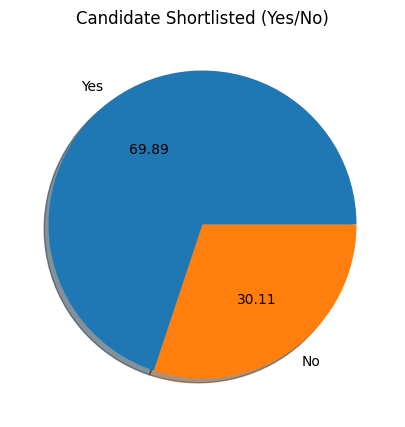

In [67]:
plt.figure(figsize=(6,5))
plt.pie(df['shortlisted'].value_counts(normalize='True'), labels=['Yes','No'], radius=1, autopct='%.2f', shadow='True')
plt.title('Candidate Shortlisted (Yes/No)')

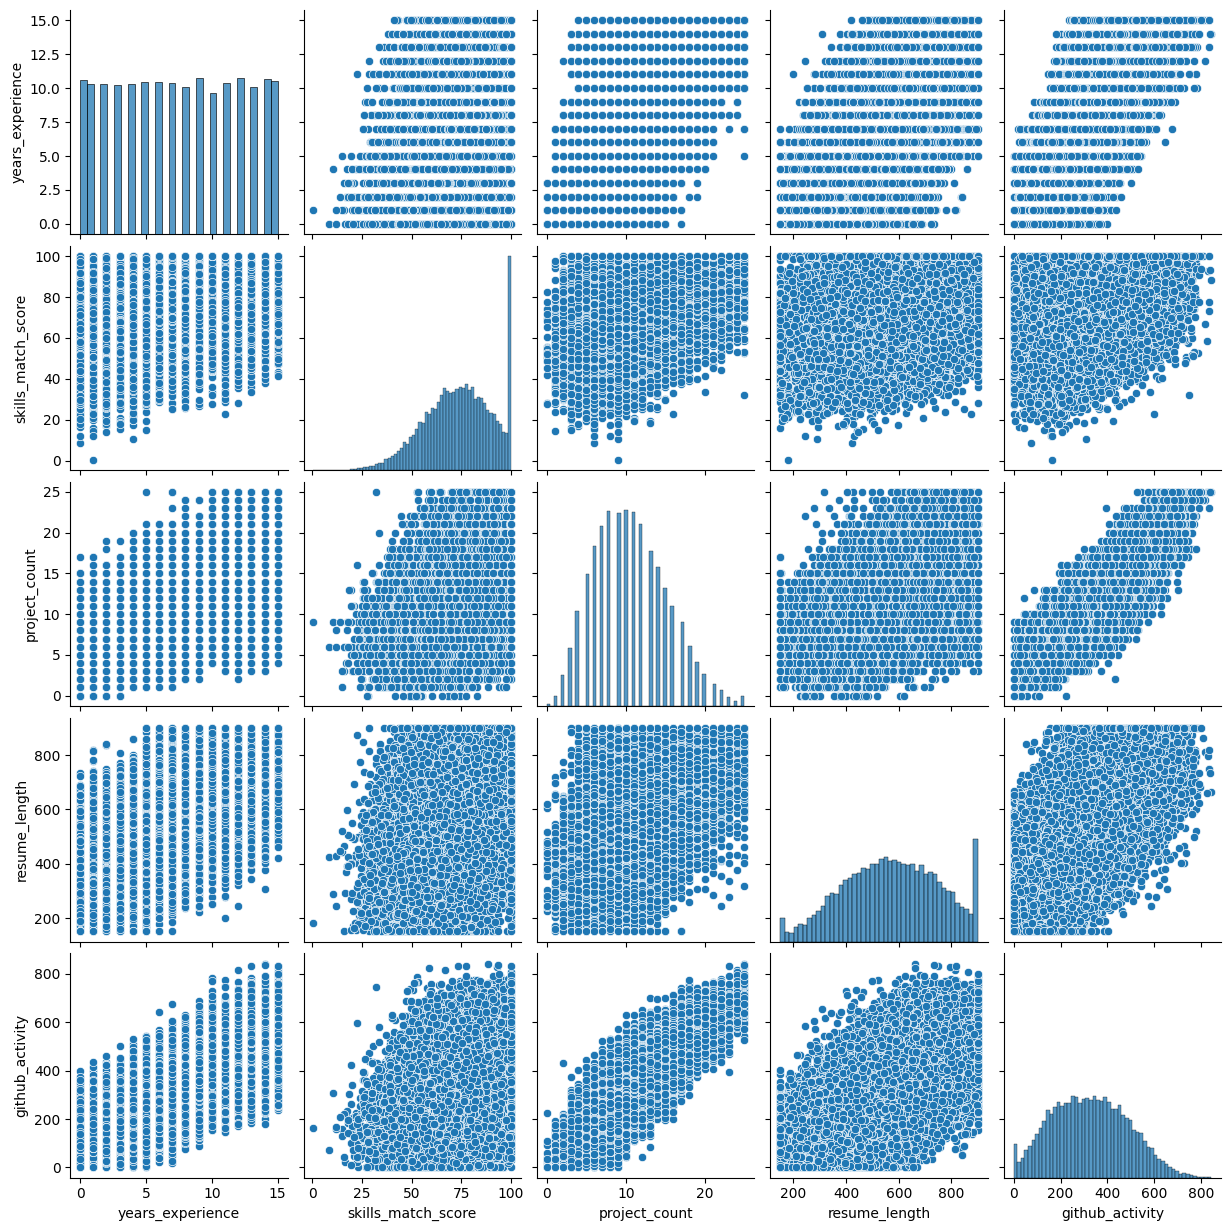

In [68]:
sns.pairplot(df)

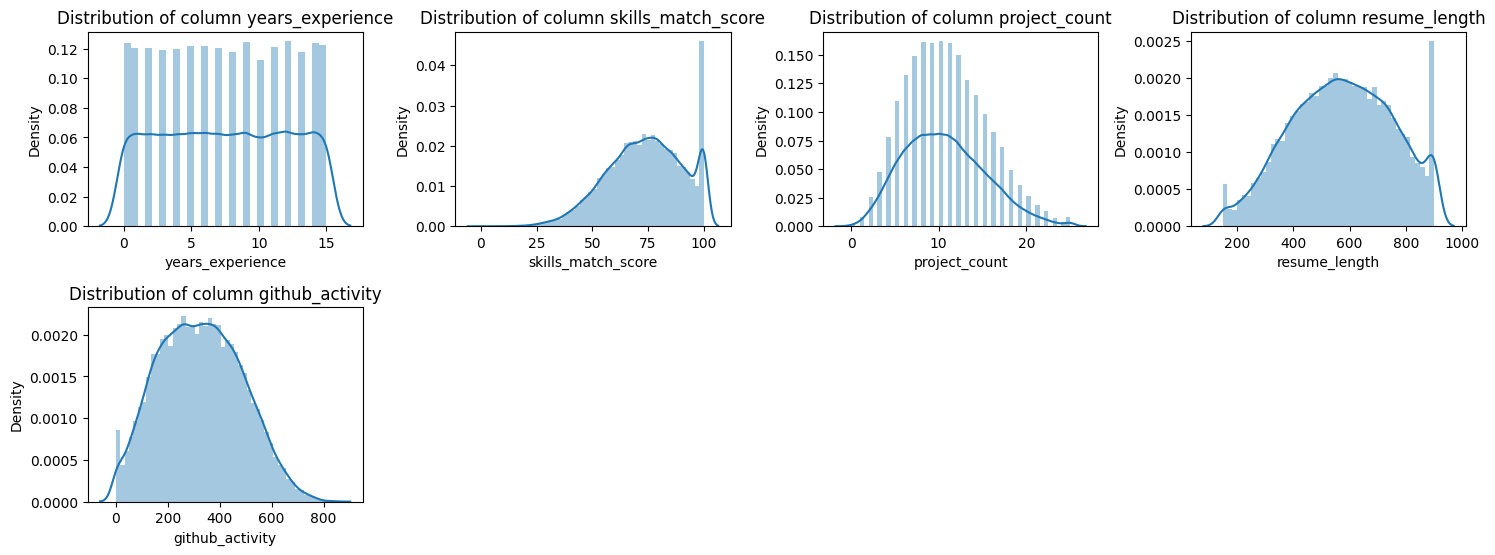

In [69]:
plt.figure(figsize=(15,30))
for i, col in enumerate(df.select_dtypes(include='number')):
   plt.subplot(11,4,i+1)
   sns.distplot(df[col])
   plt.title(f'Distribution of column {col}')
   plt.tight_layout()
   
plt.show()

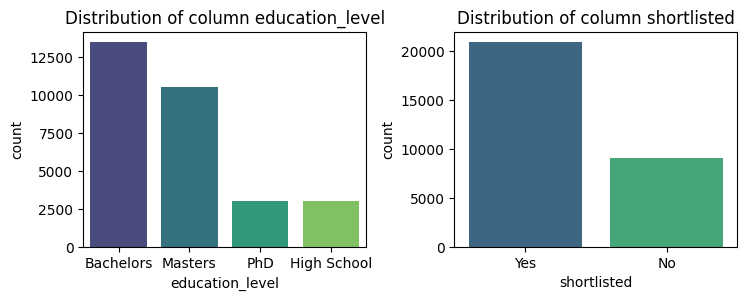

In [70]:
plt.figure(figsize=(15,30))
for i, col in enumerate(df.select_dtypes(include='object')):
   plt.subplot(11,4,i+1)
   sns.barplot(df[col].value_counts(), palette='viridis')
   plt.title(f'Distribution of column {col}')
   plt.tight_layout()
   
plt.show()

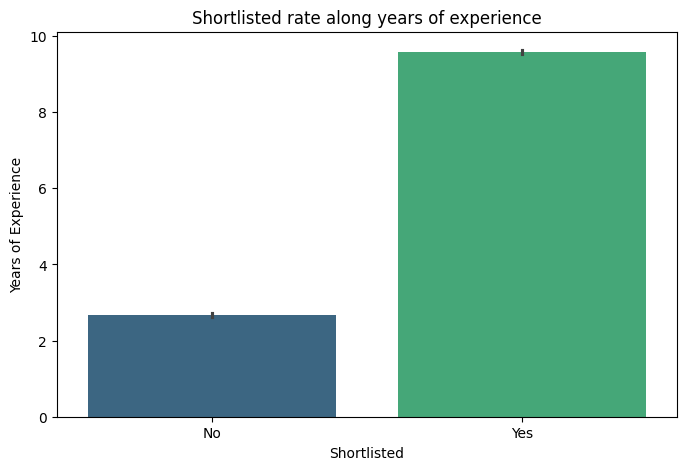

In [71]:
plt.figure(figsize=(8,5))
sns.barplot(x=df['shortlisted'], y=df['years_experience'], palette='viridis')
plt.title('Shortlisted rate along years of experience')
plt.xlabel('Shortlisted')
plt.ylabel('Years of Experience')
plt.show()

<Axes: >

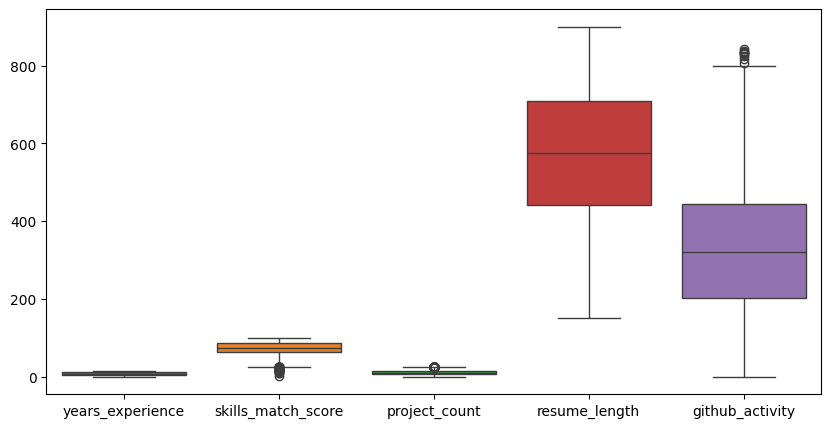

In [72]:
plt.figure(figsize=(10,5))
sns.boxplot(df)

<Axes: ylabel='Count'>

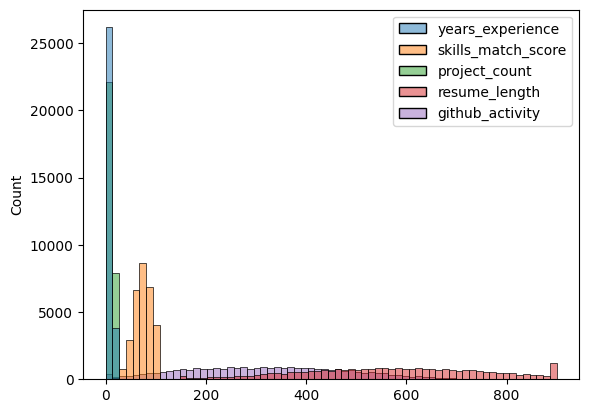

In [73]:
sns.histplot(df)

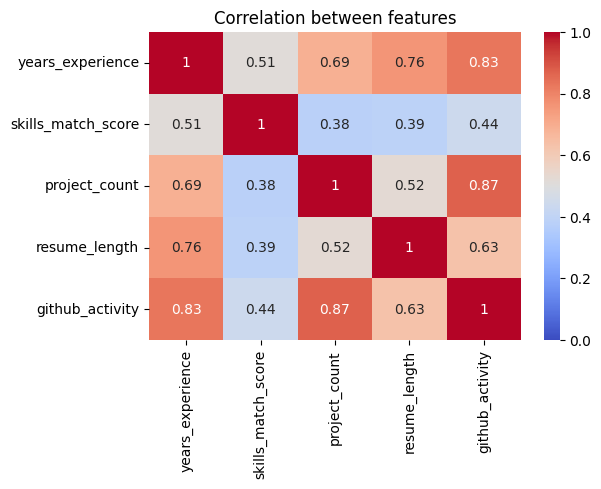

In [74]:
num_cols = df.select_dtypes(include='number')
corr_matrix = num_cols.corr()

plt.figure(figsize=(6,4))
plt.title('Correlation between features')
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm', vmin=0, vmax=1)
plt.show()

In [75]:
labelE = LabelEncoder()

df['shortlisted'] = labelE.fit_transform(df['shortlisted'])

In [76]:
X = df.drop(columns='shortlisted')
y = df['shortlisted']

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
num_columns = ['years_experience',
 'skills_match_score',
 'project_count',
 'resume_length',
 'github_activity']

num_pipeline = Pipeline(
   steps=[
      ('scaling', StandardScaler())
   ]
)


In [79]:
cat_columns = ['education_level']

cat_pipeline = Pipeline(steps=[
   ('ordinalE', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [80]:
preprocessor = ColumnTransformer(transformers=[
   ('num_pipeline', num_pipeline, num_columns),
   ('cat_pipeline', cat_pipeline, cat_columns)
])

In [81]:
model = Pipeline(steps=[
   ('preprocessor', preprocessor),
   ('model',LogisticRegression())
])

In [82]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_pipeline',
                                                  Pipeline(steps=[('scaling',
                                                                   StandardScaler())]),
                                                  ['years_experience',
                                                   'skills_match_score',
                                                   'project_count',
                                                   'resume_length',
                                                   'github_activity']),
                                                 ('cat_pipeline',
                                                  Pipeline(steps=[('ordinalE',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['education_level'])])),
                ('model', LogisticRegression())])

In [83]:
y_pred = model.predict(X_test)

In [84]:
print("Accuracy Score : ", 100 * accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy Score :  90.03333333333333
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1832
           1       0.93      0.93      0.93      4168

    accuracy                           0.90      6000
   macro avg       0.88      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



In [85]:
cv_score = cross_val_score(model, X, y, cv=5)
print("Cross validation score : ", 100 * cv_score.mean())

Cross validation score :  90.51


In [86]:
df.columns

Index(['years_experience', 'skills_match_score', 'education_level',
       'project_count', 'resume_length', 'github_activity', 'shortlisted'],
      dtype='object')

In [87]:
features = ['education_level', 'years_experience','skills_match_score',
            'project_count','resume_length','github_activity']
x_new = pd.DataFrame([['High School',14,66,8, 566, 407]], columns=features)
res = model.predict(x_new)
print('Shortlisted' if res[0] == 1 else 'Rejected')

Shortlisted


In [88]:
df.head()

,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,0
1,3,59.1,Masters,5,502,77,0
2,12,100.0,Masters,12,753,381,1
3,14,66.8,High School,8,529,407,1
4,10,99.6,Bachelors,10,754,331,1


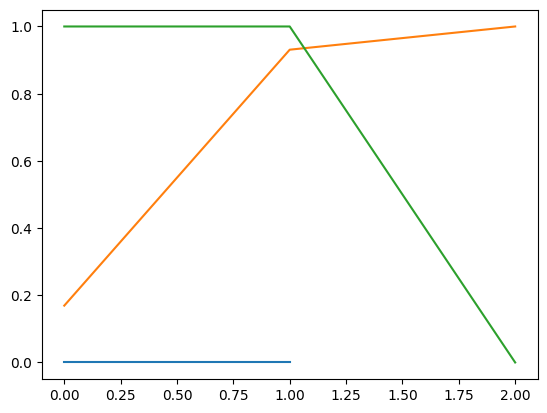

In [90]:
from sklearn.metrics import roc_curve

plt.plot(roc_curve(y_test, y_pred))

In [96]:
joblib.dump(model,"Resume_Prediction.joblib")

['Resume_Prediction.joblib']

In [100]:
pickle.dump(model, open("Resume_Prediction.pkl", "wb"))